## Imports das Bibliotecas

In [1]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Analise dos dados

In [2]:
df = pd.read_csv("cor_da_justica.csv")
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "cpf", ]
df = df.drop(columns=remover_colunas)
df = df.dropna(subset=["ementa"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11432 entries, 0 to 11736
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ementa                 11432 non-null  object
 1   ementaDetalhada        491 non-null    object
 2   ano                    11432 non-null  int64 
 3   keywords               5072 non-null   object
 4   nome                   11432 non-null  object
 5   sexo                   11432 non-null  object
 6   nascimento             11432 non-null  object
 7   local_nascimento       11432 non-null  object
 8   escolaridade           11170 non-null  object
 9   uris.uriPartido        11432 non-null  object
 10  ementa_principal       11432 non-null  object
 11  situacao               2068 non-null   object
 12  tipo                   2242 non-null   object
 13  keywords_principal     2219 non-null   object
 14  nome_partido           11432 non-null  object
 15  sigla_partido          1

In [3]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [4]:
df = df.drop(columns=["ementaDetalhada", "ementa_principal", 'keywords', 'keywords_principal'])

In [5]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"
df["situacao"] = df["situacao"].fillna("RECUSADO")

C:\Users\alexa\AppData\Local\Temp\ipykernel_29196\1803048690.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["

In [6]:
df["sexo"].value_counts()

sexo
M    8718
F    2714
Name: count, dtype: int64

In [7]:
df["ementa"].dropna().count()

11432

## Bag Of Words

In [8]:
# nltk.download('stopwords')

In [9]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [10]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab

array(['00', '000', '0001', ..., 'úteis', 'útero', 'útil'], dtype=object)

## WORD CLOUD

In [11]:
le = LabelEncoder()

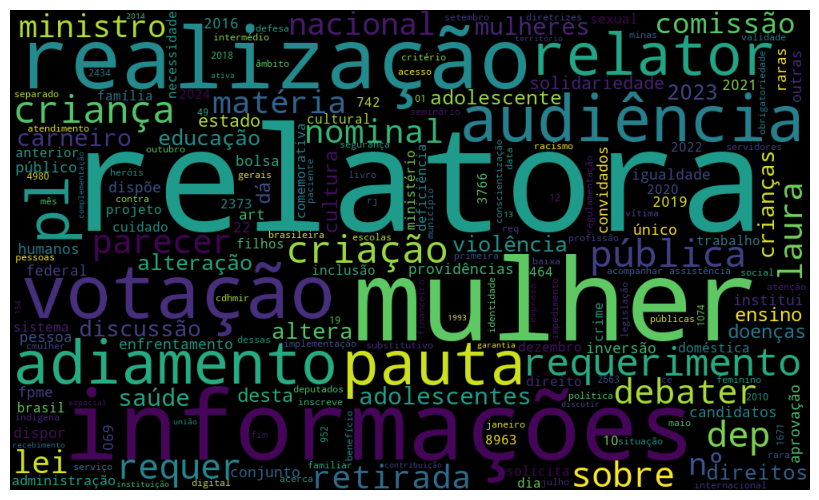

In [12]:
model = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)
y = le.fit_transform(df["sexo"])
X_train, X_test, y_train, y_test = train_test_split(X, y)
model.fit(X_train, y_train)
features_importance = model.feature_importances_
features_name = tf_idf.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

In [13]:
df_masculino = df[df["sexo"] == "M"].reset_index(drop=True)
df_feminino = df[df["sexo"] == "F"].reset_index(drop=True)

tf_idf_masculino = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
tf_idf_feminino = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )

y_masculino = le.fit_transform(df_masculino["situacao"])
y_feminino = le.fit_transform(df_feminino["situacao"])

In [14]:
X_masculino = tf_idf_masculino.fit_transform(df_masculino["ementa"])
vocab_masculino = tf_idf_masculino.get_feature_names_out()


In [15]:
X_feminino = tf_idf_feminino.fit_transform(df_feminino["ementa"])
vocab_feminino = tf_idf_feminino.get_feature_names_out()



## GRUPO 1: MASCULINO

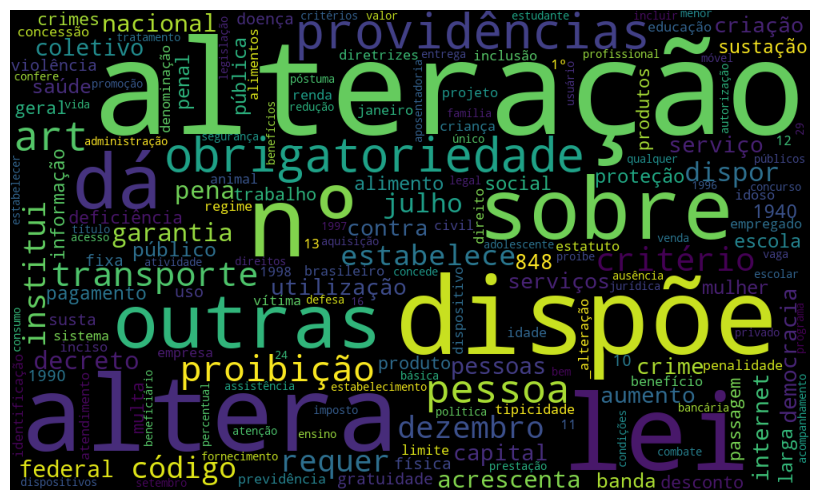

In [16]:
model_masculino = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)

X_train_masculino, X_test_masculino, y_train_masculino, y_test__masculino = train_test_split(X_masculino, y_masculino)
model_masculino.fit(X_train_masculino, y_train_masculino)
features_importance_masculino = model_masculino.feature_importances_
features_name_masculino = tf_idf_masculino.get_feature_names_out()
word_importance_masculino = dict(zip(features_name_masculino, features_importance_masculino))

wordcloud_masculino = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance_masculino)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud_masculino) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

## GRUPO 2: FEMININO 

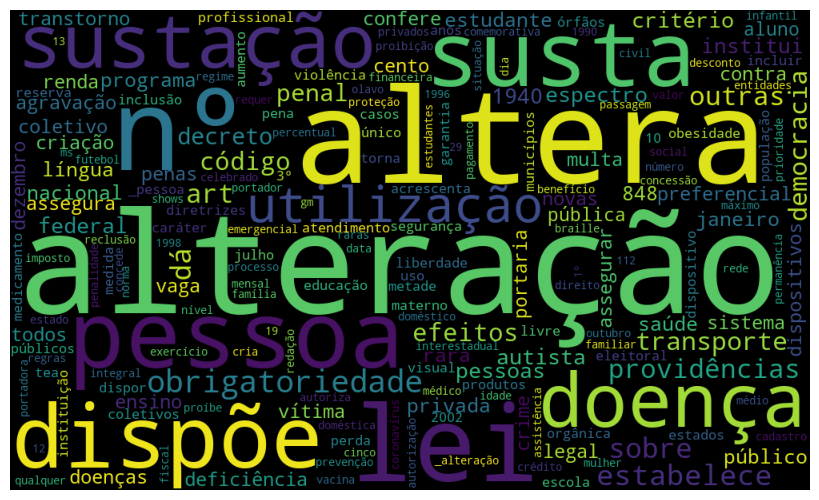

In [17]:
model_feminino = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)

X_train_feminino, X_test_feminino, y_train_feminino, y_test_feminino = train_test_split(X_feminino, y_feminino)
model_feminino.fit(X_train_feminino, y_train_feminino)
features_importance_feminino = model_feminino.feature_importances_
features_name_feminino = tf_idf_feminino.get_feature_names_out()
word_importance_feminino = dict(zip(features_name_feminino, features_importance_feminino))

wordcloud_feminino = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance_feminino)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud_feminino) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

In [18]:
df["sexo"]

0        M
1        M
2        M
3        M
4        M
        ..
11427    F
11428    M
11429    M
11430    M
11431    M
Name: sexo, Length: 11432, dtype: object

## PCA

In [19]:
le = LabelEncoder()

df["sexo"] = le.fit_transform(df["sexo"])
y = df["sexo"]

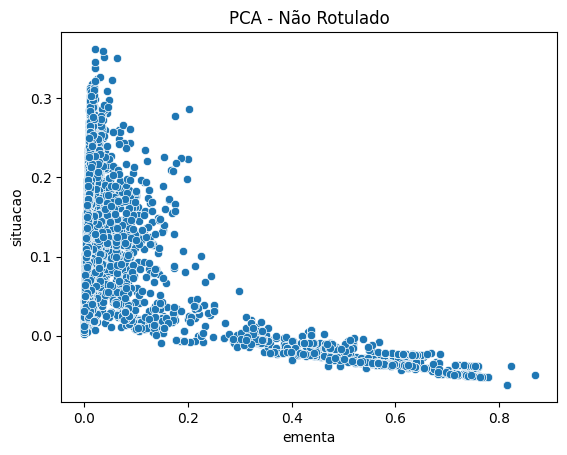

In [20]:
pca = TruncatedSVD(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'situacao'])
df_pca["target"] = df["sexo"].reset_index(drop=True)


sns.scatterplot(x='ementa', y="situacao", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

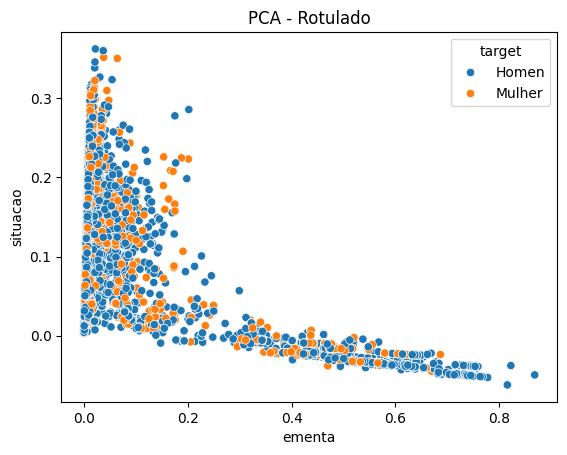

In [21]:
y_map = {0: 'Mulher', 1: "Homen"}

df_pca["target"] = df["sexo"].map(y_map)

sns.scatterplot(x='ementa', y="situacao", hue="target", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

## Treino do Modelo

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE(random_state=42)
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [24]:
## Funçao para Avaliação dos Modelos

def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Feminino", "Masculino"])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [25]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42) 

# Logistic Regression

In [26]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)


print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.62243845 0.64125348 0.63776027 0.6608326  0.63182794]
Media da Accuracy:  0.798461539050076
Media da MACRO F1:  0.6388225494944331
Desvio Padrão da MACRO F1:  0.012718833207158357


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.47      0.53      0.50       548
           1       0.84      0.81      0.83      1739

    accuracy                           0.75      2287
   macro avg       0.66      0.67      0.66      2287
weighted avg       0.76      0.75      0.75      2287



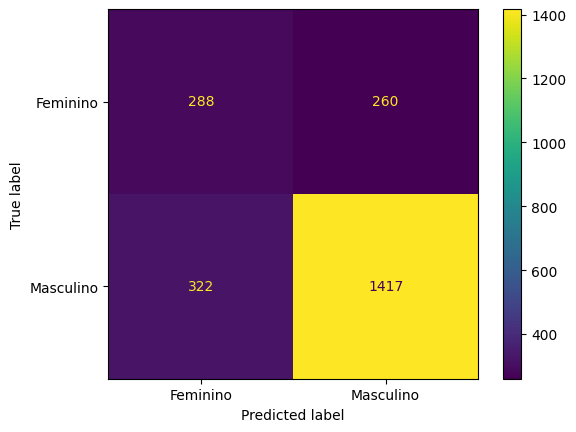

In [27]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [28]:
model_SGD = SGDClassifier(random_state=42, loss="perceptron", alpha=0.002, learning_rate="optimal", eta0=0.1, power_t=0.2, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.62409259 0.63597709 0.63236068 0.65765452 0.65243764]
Media da Accuracy:  0.7262964505912494
Media da MACRO F1:  0.640504504889714
Desvio Padrão da MACRO F1:  0.012591210977489302


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.45      0.43      0.44       548
           1       0.82      0.83      0.83      1739

    accuracy                           0.74      2287
   macro avg       0.64      0.63      0.63      2287
weighted avg       0.73      0.74      0.73      2287



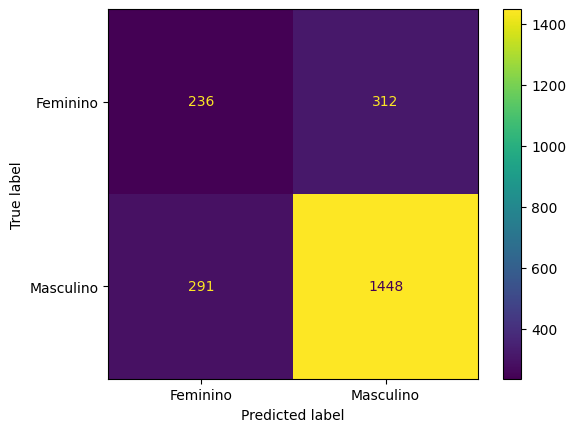

In [29]:
model_SGD.fit(X_train, y_train)
y_pred = model_SGD.predict(X_test)
evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# K Neighbors Classifier

In [30]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="uniform", algorithm="auto", leaf_size=50, p=2 )
cross_val_results = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracy = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.6409525  0.64312497 0.6525988  0.66706487 0.6464241 ]
Media da Accuracy:  0.7812291008442485
Media da MACRO F1:  0.6500330476120926
Desvio Padrão da MACRO F1:  0.009379430993072226


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.31      0.86      0.46       548
           1       0.90      0.41      0.56      1739

    accuracy                           0.51      2287
   macro avg       0.61      0.63      0.51      2287
weighted avg       0.76      0.51      0.54      2287



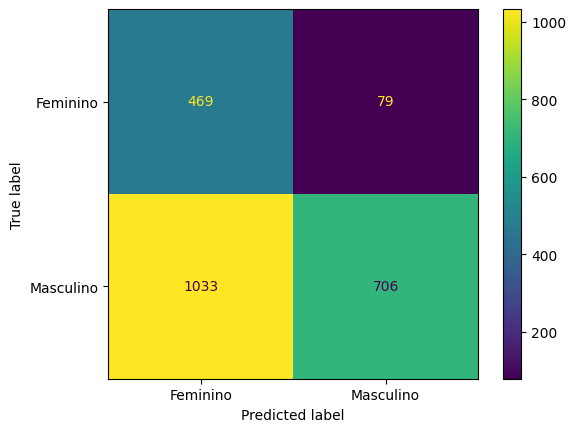

In [31]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [32]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=1, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.65736048 0.6659336  0.66646101 0.69467641 0.66362757]
Media da Accuracy:  0.7482518828128557
Media da MACRO F1:  0.66961181315489
Desvio Padrão da MACRO F1:  0.012942932422770703


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.47      0.51      0.49       548
           1       0.84      0.82      0.83      1739

    accuracy                           0.75      2287
   macro avg       0.66      0.66      0.66      2287
weighted avg       0.75      0.75      0.75      2287



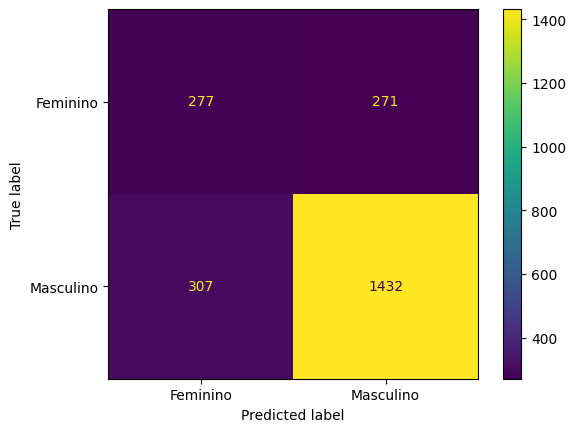

In [33]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [34]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=1000, criterion="entropy", max_features='log2', class_weight='balanced', n_jobs=-1, )
cross_val_results = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.62480249 0.61497254 0.62807924 0.64008215 0.6065929 ]
Media da Accuracy:  0.7952247114716257
Media da MACRO F1:  0.6229058658348074
Desvio Padrão da MACRO F1:  0.011440597995216803


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.65      0.36      0.46       548
           1       0.82      0.94      0.88      1739

    accuracy                           0.80      2287
   macro avg       0.74      0.65      0.67      2287
weighted avg       0.78      0.80      0.78      2287



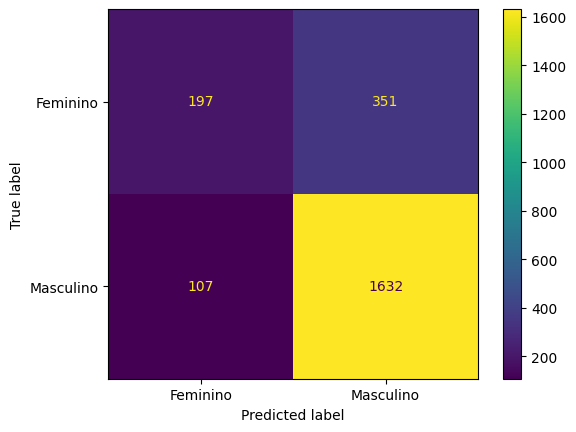

In [35]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [36]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, max_leaf_nodes=50, criterion="gini", splitter="best", class_weight="balanced" )
cross_val_results = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.61203036 0.59425392 0.63312543 0.61991192 0.61600791]
Media da Accuracy:  0.6758251305163155
Media da MACRO F1:  0.6150659089905
Desvio Padrão da MACRO F1:  0.012592622985369046


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.40      0.48      0.43       548
           1       0.82      0.77      0.80      1739

    accuracy                           0.70      2287
   macro avg       0.61      0.62      0.61      2287
weighted avg       0.72      0.70      0.71      2287



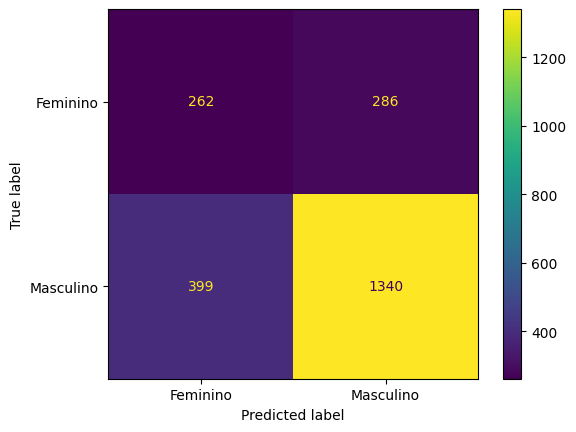

In [37]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)